<a href="https://colab.research.google.com/github/sadasivam009/bike-sharing-demand-reg-/blob/main/Clus_%5BMall_Customer_Segmentation_Data%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Mall Customer Segmentation Data**

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
pd.options.display.max_columns = 50
from sklearn.decomposition import PCA

In [25]:
df = pd.read_csv('/content/sample_data/archive.zip')

In [26]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0
...,...,...,...,...,...
995,1995,M,80.0,133.3,1.0
996,1996,M,44.0,82.6,40.0
997,1997,F,46.0,67.7,26.0
998,1998,F,28.0,45.7,59.0


In [27]:
df.head()
df.tail()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
995,1995,M,80.0,133.3,1.0
996,1996,M,44.0,82.6,40.0
997,1997,F,46.0,67.7,26.0
998,1998,F,28.0,45.7,59.0
999,1999,M,67.0,107.8,1.0


In [28]:
df.shape

(1000, 5)

In [29]:
df.info()

print("describe : ", df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB
describe :          CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  1000.000000  994.000000          996.000000              994.000000
mean   1499.500000   38.935614           57.149096               42.645875
std     288.819436   13.399880           28.628506               20.101589
min    1000.000000   18.000000           15.000000                1.000000
25%    1249.750000   30.000000           34.975000               31.000000

In [30]:
df.isnull().sum()

,0
CustomerID,0
Gender,3
Age,6
Annual Income (k$),4
Spending Score (1-100),6


In [31]:
df.duplicated().sum()

np.int64(0)

In [38]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [41]:
df.nunique()

,0
CustomerID,1000
Gender,2
Age,62
Annual Income (k$),592
Spending Score (1-100),84


In [40]:
df.dtypes

,0
CustomerID,int64
Gender,object
Age,float64
Annual Income (k$),float64
Spending Score (1-100),float64


In [42]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
995,False
996,False
997,False
998,False


In [44]:
LE  = LabelEncoder()
df['Age'] = LE.fit_transform(df['Age'])

In [45]:
df['Age']

,Age
0,21
1,16
2,22
3,29
4,15
...,...
995,61
996,26
997,28
998,10


In [48]:
x = df.iloc[:,:]

In [67]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(x_scaled)

In [68]:
X_pca

array([[-0.4055313 ,  1.04288036],
       [-0.25874819,  1.04580737],
       [ 0.80291948, -0.93541448],
       ...,
       [ 0.9993865 , -0.93005982],
       [-1.14886229, -0.97655241],
       [ 3.37758758,  1.12347969]])

In [69]:
pca.explained_variance_ratio_.cumsum()[1]

np.float64(0.9212326179477643)

In [70]:
distortion = []
for i in range(1,11):
  km = KMeans(n_clusters=i,init='k-means++',random_state=42,n_init=10)
  km.fit(X_pca)
  distortion.append(km.inertia_)

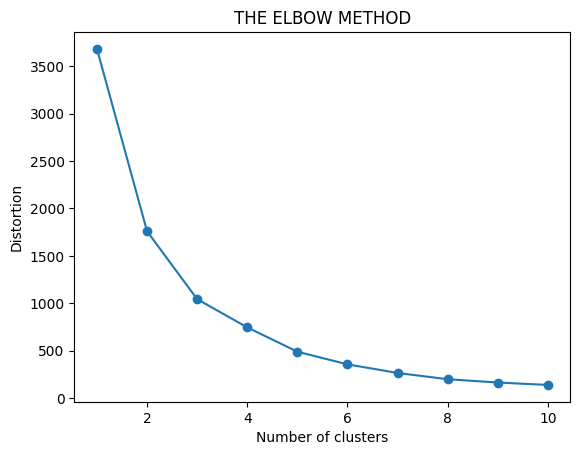

In [71]:
plt.plot(range(1,11),distortion,marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.title('THE ELBOW METHOD')
plt.show()

In [82]:
model = KMeans(n_clusters=5,init='k-means++',random_state=42,n_init=10)
model.fit(X_pca)

KMeans(n_clusters=5, n_init=10, random_state=42)

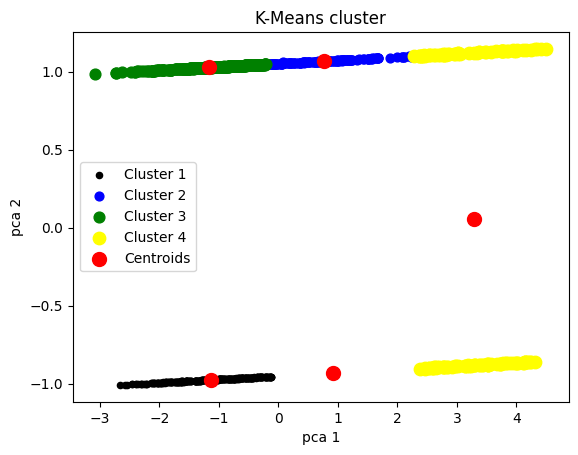

In [81]:
plt.scatter(X_pca[y==0,0],X_pca[y==0,1],s=20,c='black',label='Cluster 1')
plt.scatter(X_pca[y==1,0],X_pca[y==1,1],s=40,c='blue',label='Cluster 2')
plt.scatter(X_pca[y==2,0],X_pca[y==2,1],s=60,c='green',label='Cluster 3')
plt.scatter(X_pca[y==3,0],X_pca[y==3,1],s=80,c='yellow',label='Cluster 4')
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=100,c='red',label='Centroids')
plt.title('K-Means cluster')
plt.xlabel('pca 1')
plt.ylabel('pca 2')
plt.legend()
plt.show()